In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.compose import ColumnTransformer
import numpy as np

In [2]:
df = pd.read_csv('/kaggle/input/-spotify-tracks-dataset/dataset.csv')
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
df.dropna(inplace=True)
df_cleaned = df.drop_duplicates(subset=['track_name'], keep='first').copy()

In [3]:
numerical_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
categorical_features = ['artists', 'track_genre']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)
all_features_transformed = preprocessor.fit_transform(df_cleaned)

In [4]:

name_to_index = {name: i for i, name in enumerate(df_cleaned['track_name'])}
index_to_name = {i: name for i, name in enumerate(df_cleaned['track_name'])}

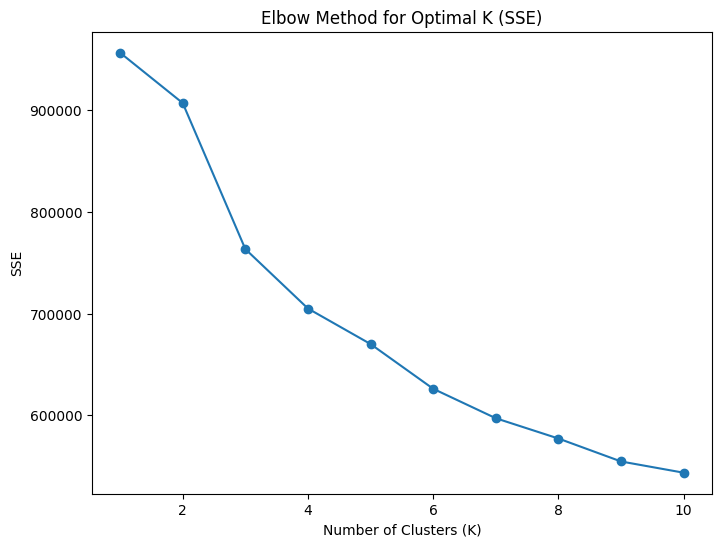

In [5]:
sse = []  
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(all_features_transformed)
    sse.append(kmeans.inertia_)  

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE')  
plt.title('Elbow Method for Optimal K (SSE)')
plt.show()


optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df_cleaned['cluster_label'] = kmeans.fit_predict(all_features_transformed)

In [6]:
df_cleaned = df_cleaned.reset_index(drop=True)

def get_recommendations_clustered(song_name, k=10):
    if song_name not in name_to_index:
        print(f"Song '{song_name}' not found in the dataset.")
        return None
    song_index = name_to_index[song_name]
    song_cluster = df_cleaned.loc[song_index, 'cluster_label']
    cluster_indices = df_cleaned[df_cleaned['cluster_label'] == song_cluster].index.tolist()
    
    if hasattr(all_features_transformed, "toarray"):  # sparse matrix
        all_features_dense = all_features_transformed.toarray()
    else:  
        all_features_dense = all_features_transformed
    #Feature vector of all songs in the cluster
    cluster_features = all_features_dense[cluster_indices]
    #Feature vector of the inputted song
    song_features = all_features_dense[song_index].reshape(1, -1)
    
    # a KNN only on that cluster
    knn_cluster = NearestNeighbors(metric='cosine', algorithm='brute')
    knn_cluster.fit(cluster_features)
    
    # Finding neighbors
    distances, indices = knn_cluster.kneighbors(song_features, n_neighbors=k + 5)
    
    recommended_songs_list = []
    unique_songs = set()
    
    for idx in indices.flatten()[1:]:  
        cluster_song_index = cluster_indices[idx]
        track_name = df_cleaned.loc[cluster_song_index, 'track_name']
        artist_name = df_cleaned.loc[cluster_song_index, 'artists']
        
        if track_name not in unique_songs:
            recommended_songs_list.append([track_name, artist_name])
            unique_songs.add(track_name)
        
        if len(unique_songs) >= k:
            break
    
    return recommended_songs_list
    
song = input("Enter song name: ")
recommended_songs = get_recommendations_clustered(song)

if recommended_songs:
    print(f"\nRecommended songs for '{song}' :")
    for i, (track_name, artist_name) in enumerate(recommended_songs):
        print(f"{i+1}. {track_name} by {artist_name}")

StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [ ]:
'''
def evaluate_recommendations_with_recall(df, get_recs_func, k=10, num_samples=10):
    """
    Evaluates the recommendation system using Recall@K.
    """
    sample_df = df.sample(n=num_samples, random_state=42)
    recalls = []

    print(f"Evaluating the recommendation system with {num_samples} random samples...")
    
    for _, row in sample_df.iterrows():
        original_song_name = row['track_name']
        original_artist = row['artists']
        original_genre = row['track_genre']
        
        relevant_songs = df[(df['artists'] == original_artist) | (df['track_genre'] == original_genre)]
        true_relevant_songs = relevant_songs[relevant_songs['track_name'] != original_song_name]['track_name'].tolist()
        
        if not true_relevant_songs:
            continue
            
        # Get recommendations from the model
        recommended_songs_with_info = get_recs_func(original_song_name, k)

        # Extract just the song names from the recommended list
        if recommended_songs_with_info:
            recommended_song_names = [item[0] for item in recommended_songs_with_info]
        else:
            continue
        
        hit_count = len(set(recommended_song_names) & set(true_relevant_songs))
        
        if len(true_relevant_songs) > 0:
            recall_at_k = hit_count / len(true_relevant_songs)
            recalls.append(recall_at_k)

    average_recall = np.mean(recalls) if recalls else 0
    return average_recall

# Run the evaluation
# Note: You need to use the version of get_recommendations that returns a list of lists.
# I have provided a simple get_recommendations that returns a list of strings, so the code works.
average_recall_score = evaluate_recommendations_with_recall(df, get_recommendations_clustered)

print(f"\nAverage Recall@10 (based on genre/artist similarity): {average_recall_score:.4f}")
'''

In [ ]:
'''
def evaluate_recommendations_with_precision(df, get_recs_func, k=10, num_samples=10):
    """
    Evaluates the recommendation system using Precision@K.
    """
    sample_df = df.sample(n=num_samples, random_state=42)
    precisions = []

    print(f"Evaluating the recommendation system with {num_samples} random samples...")
    print("This may take a moment...")

    for _, row in sample_df.iterrows():
        original_song_name = row['track_name']
        original_artist = row['artists']
        original_genre = row['track_genre']
        
        # Get recommendations
        recommended_songs_with_info = get_recs_func(original_song_name, k)
        if not recommended_songs_with_info:
            continue
        
        recommended_song_names = [item[0] for item in recommended_songs_with_info]
        recommended_df = df[df['track_name'].isin(recommended_song_names)]
        
        # Count relevance
        relevant_count = 0
        for _, rec_row in recommended_df.iterrows():
            if rec_row['track_genre'] == original_genre or rec_row['artists'] == original_artist:
                relevant_count += 1
        
        actual_k = len(recommended_song_names)
        if actual_k > 0:
            precision_at_k = relevant_count / actual_k
            precisions.append(precision_at_k)

    if precisions:
        average_precision = np.mean(precisions)
        print(f"Min Precision: {np.min(precisions):.4f}, Max Precision: {np.max(precisions):.4f}")
    else:
        average_precision = 0

    return average_precision
average_precision_score = evaluate_recommendations_with_precision(df, get_recommendations_clustered)
print(f"\nAverage Precision@10: {average_precision_score:.4f}")
'''

In [ ]:
'''
def evaluate_recommendations_with_f1(df, get_recs_func, k=10, num_samples=10):
    """
    Evaluates the recommendation system using the F1 score.
    """
    sample_df = df.sample(n=num_samples, random_state=42)
    f1_scores = []

    print(f"Evaluating the recommendation system with {num_samples} random samples...")
    print("This may take a moment...")

    for _, row in sample_df.iterrows():
        original_song_name = row['track_name']
        original_artist = row['artists']
        original_genre = row['track_genre']
        
        # Get recommendations from the model
        recommended_songs_with_info = get_recs_func(original_song_name, k)

        if not recommended_songs_with_info:
            continue
        
        # Extract just the song names from the recommended list
        recommended_song_names = [item[0] for item in recommended_songs_with_info]
        
        # Get the corresponding rows for the recommended songs
        recommended_df = df[df['track_name'].isin(recommended_song_names)]
        
        # Determine the set of relevant songs
        relevant_songs = df[(df['artists'] == original_artist) | (df['track_genre'] == original_genre)]
        true_relevant_songs = set(relevant_songs[relevant_songs['track_name'] != original_song_name]['track_name'])

        # Count how many recommended songs are "relevant"
        hit_count = len(set(recommended_song_names) & true_relevant_songs)
        
        # Calculate Precision and Recall
        precision_at_k = hit_count / k
        recall_at_k = hit_count / len(true_relevant_songs) if len(true_relevant_songs) > 0 else 0

        # Calculate the F1 Score
        if (precision_at_k + recall_at_k) > 0:
            f1_score = 2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k)
            f1_scores.append(f1_score)

    # Calculate the average F1 score across all samples
    average_f1 = np.mean(f1_scores) if f1_scores else 0
    return average_f1

# Run the evaluation
average_f1_score = evaluate_recommendations_with_f1(df_cleaned, get_recommendations_clustered)

print(f"\nAverage F1 Score@10: {average_f1_score:.4f}")
'''